In [121]:
import networkx as nx
import json
import pandas as pd
import numpy as np
from collections import defaultdict
import ast

import nltk
from nltk import word_tokenize
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import MWETokenizer
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\julie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Plot parameters:

In [133]:
import matplotlib as mpl
import matplotlib.pylab as plt
def setup_mpl():
    mpl.rcParams["font.size"] = 11
    mpl.rcParams["figure.figsize"] = (7,3)
    mpl.rcParams["figure.dpi"] = 400
setup_mpl()

# Import dataset

Import combined dataset with subreddits and their description:

In [136]:
url_df = pd.read_csv("../data/COMBINED.csv")
url_df

,title,description,display_name,url,subreddit_name
0,Not Safe for Work,#### AVOID REPOSTS!!! Check [KarmaDecay.com](...,nsfw,/r/nsfw/,nsfw
1,features,"/r/features, the second subreddit ever created...",features,/r/features/,features
2,"Citius, Altius, Fortius",> [Paris2024.org](www.paris2024.org)\n\nMEDAL ...,olympics,/r/olympics/,olympics
3,"r/de – Nett hier, aber waren Sie schon mal in ...",**Für alle Deutschsprechenden. Die [Hausordnun...,de,/r/de/,de
4,r/ES - Comunidad española para contenido que n...,"**Reddit para España, sus habitantes y visitan...",es,/r/es/,es
...,...,...,...,...,...
11234,Walk the Moon,----------------------------------------------...,walkthemoon,/r/walkthemoon/,walkthemoon
11235,Wallpaper Dump,**Dump your wallpapers!**\n\nBecause having no...,wallpaperdump,/r/wallpaperdump/,wallpaperdump
11236,witchhouse,For sharing and discussing music witch house f...,witchhouse,/r/witchhouse/,witchhouse
11237,wrong_subreddit,This subreddit is for acting like you posted a...,wrong_subreddit,/r/wrong_subreddit/,wrong_subreddit


# Initial text processing and text analysis

We do text preprocessing:

- Remove puncuation, URLs, special characters and numbers
- Convert to lowercase
- Tokenize
- Remove stopwords


In [137]:
def get_tokenization_and_remove_stop_words(text):
    text = text.lower() # Maker text lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Delete URLs
    text = re.sub(r'[^a-z\s]', '', text) # Remove all punctuation and numbers
    tokens = word_tokenize(text) # Tokenize
    tokens = [t for t in tokens if t.strip()] # Avoid empty tokens

    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words] # Remove stopwords
    return tokens 

url_df["tokens"] = url_df["description"].apply(get_tokenization_and_remove_stop_words)

In [ ]:
# Save to CSV:
url_df.to_csv("../data/COMBINED_stop_words_removed.csv", index=False)

# Load CSV
url_df = pd.read_csv(r"../data/COMBINED_stop_words_removed.csv")
url_df["tokens"] = url_df["tokens"].apply(ast.literal_eval);

Now we create a tokens list by combining all tokens from all descriptions into one list:

In [162]:
tokens_list = []
for tokens in url_df["tokens"]:
    tokens_list += tokens

The most frequent 10 words are:

In [163]:
fdist = nltk.FreqDist(tokens_list)
most_common_10 = fdist.most_common(10)
most_common_10

[('post', 11472),
 ('posts', 9735),
 ('please', 9219),
 ('subreddit', 8550),
 ('rules', 7815),
 ('related', 5453),
 ('content', 5176),
 ('links', 5036),
 ('dont', 4827),
 ('subreddits', 4539)]

We see here that both "post" & "posts" and "subreddit" & "subreddits" are in the 10 most frequent words. 

We tried adding stemming to the preprocessing, but it did not make a change in the most 10.

Comment: We have used an english tokenizer and stemmer. Some of the subreddits are in other language but we assume that most are in english.

We make a frequency rank plot:

We plot the token frequency against the token rank on the logarithmic scale:

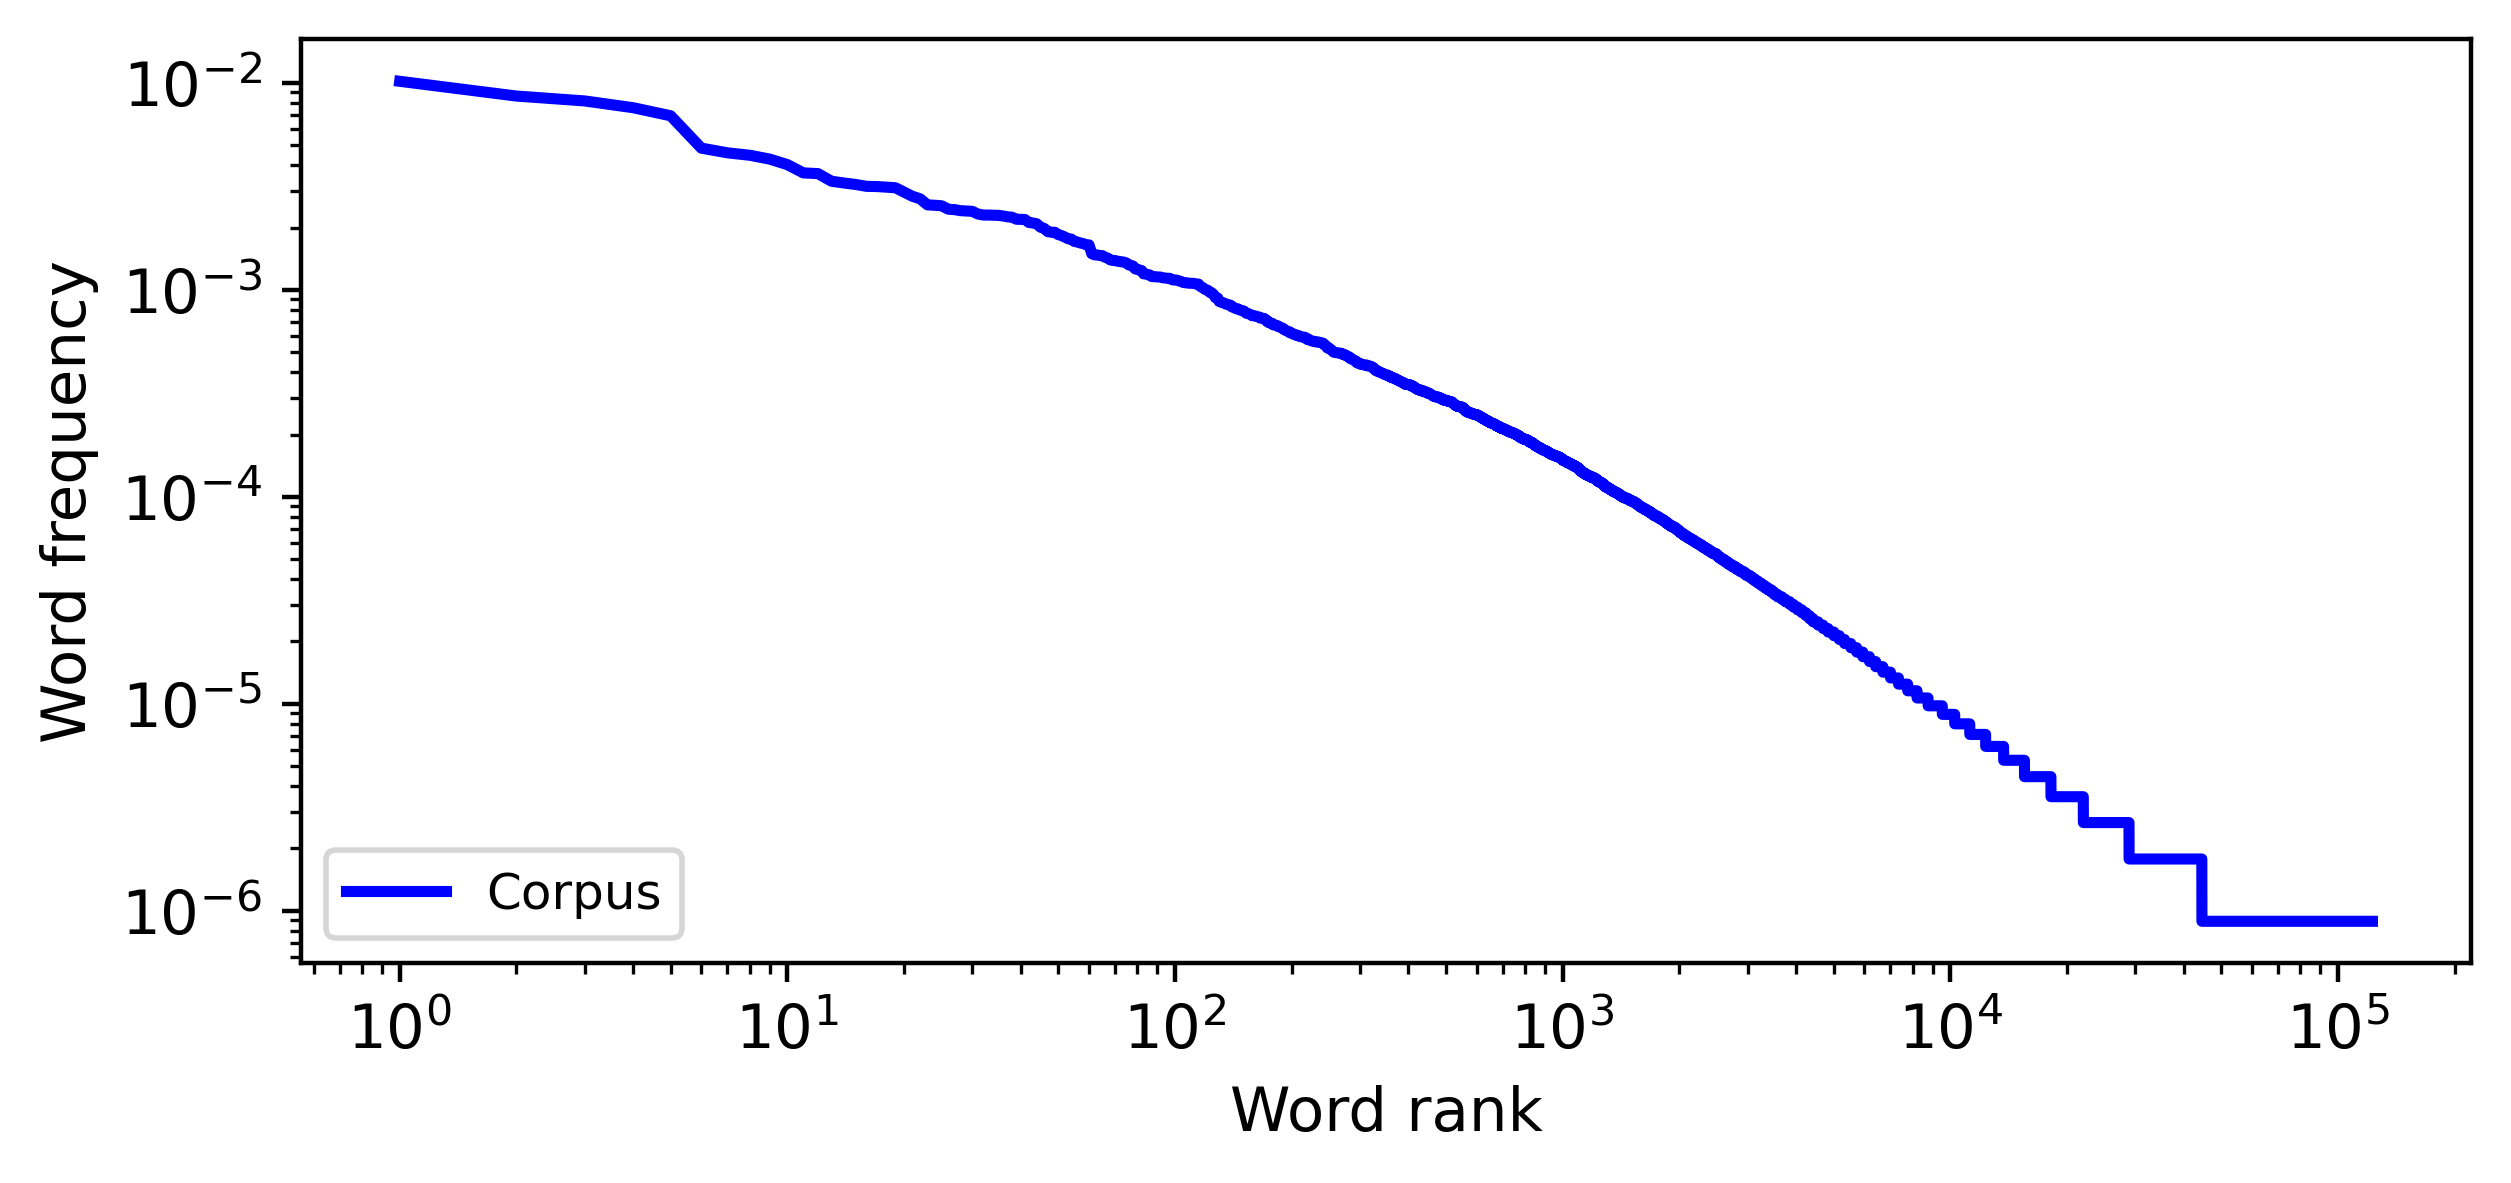

In [164]:
freqs = []
ranks = []
total = sum(fdist.values())
for i, (_,count) in enumerate(fdist.most_common(), start=1):
    ranks.append(i)
    freqs.append(count/total)

fig,ax = plt.subplots()
ax.plot(ranks,freqs, color="blue", lw=2, label="Corpus")
ax.set_xlabel("Word rank")
ax.set_ylabel("Word frequency")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend(fontsize="9", loc="lower left")
plt.show()

Straight line in log-log scale: Follows power law (heavy-tail distribution)

The weird behaviour on the line in the higher magnitudes of word rank are mostly due to noise (we cannot rely on their word frequencies because the word occur so infrequent).

# Further text processing and text analysis (collocations)

In our text preproccesing, we do NOT want to split pairs of words that constitute a collocation
- Collocations are pairs of words that tend to appear together more often than by chance.

For each bigram:
- Compute the observed contingency table:

$$O_{w_1,w_2}= \begin{bmatrix} n_{ii} & n_{io} \\ n_{oi} & n_{oo} \end{bmatrix}$$

where:

$n_{ii}$: the number of times the bigram ($w_1$, $w_2$) appear in the corpus     
$n_{io}$: the number of bigrams ($w_1$, * ), where the first element is $w_1$ and the second element is **not** $w_2$         
$n_{oi}$:  the number of bigrams ( * , $w_2$ ), where the first element is **not** $w_1$ and the second element is $w_2$    
$n_{oo}$: the number of bigrams ( * , * ) where the first element is **not** $w_1$ and the second is **not** $w_2$. 

- Compute the expected contingency table:

$$E_{w_1,w_2}= \begin{bmatrix} \frac{R_1C_1}{N} & \frac{R_1C_2}{N} \\ \frac{R_2C_1}{N} & \frac{R_2C_2}{N} \end{bmatrix}$$

$R_{1}=n_{ii}+n_{io}$: the bigrams containing the word $w_1$  (sum of first row)    
$C_{1}=n_{ii}+n_{oi}$: the bigrams containing the word $w_2$ (sum of first column)    
$R_{2}=n_{oi}+n_{oo}$: the bigrams **not** containing the word $w_1$  (sum of second row)    
$C_{2}=n_{io}+n_{oo}$: the bigrams **not** containing the word $w_2$  (sum of second column)    
$N =  the total number of bigrams


- Compare $O_{w_1,w_2}$ and $E_{w_1,w_2}$ by using the Chi-Squared test

Store all the bigrams:

In [168]:
from collections import defaultdict
abstract_bigrams = url_df["tokens"].apply(nltk.bigrams)

bigrams = defaultdict(int)
bigram_apperances_w1 = defaultdict(int)
bigram_apperances_w2 = defaultdict(int)

for bg_gen in abstract_bigrams:
    for (w1,w2) in list(bg_gen):
        bigrams[(w1,w2)] +=1
        bigram_apperances_w1[w1] +=1
        bigram_apperances_w2[w2] +=1

Compute the contingency tables:

In [170]:
observed_contingency_table = {}
expected_contingency_table = {}
total_bigrams = sum(bigrams.values())

for (w1, w2), nii in bigrams.items():
    ni0 = bigram_apperances_w1[w1] - nii
    n0i = bigram_apperances_w2[w2] - nii
    n00 = total_bigrams - nii - ni0 - n0i

    O = np.array([[nii, ni0], [n0i, n00]])
    observed_contingency_table[(w1, w2)] = O

    R1 = nii + ni0
    R2 = n0i + n00
    C1 = nii + n0i
    C2 = ni0 + n00
    N = total_bigrams  # Formlen er forkert på hjemmesiden

    E = np.array([[R1 * C1 / N, R1 * C2 / N],
                  [R2 * C1 / N, R2 * C2 / N]])
    expected_contingency_table[(w1, w2)] = E

For each unique bigram, we compute the Chi-squared statistics: $X^2 = \sum_{ij}\frac{(O_{ij} - E_{ij})^2}{E_{ij}}$, where $O_{ij}$ and $E_{ij}$ are the elements of the observed and expected matrix, respectively. 

In [172]:
from scipy.stats import chi2
chi2_stats = {}
p_values = {}

for bigram in bigrams.keys():
    chi_squared = np.sum((observed_contingency_table[bigram]-expected_contingency_table[bigram])**2/expected_contingency_table[bigram])
    chi2_stats[bigram] = chi_squared
    p_values[bigram] = chi2.sf(chi_squared,df=1)

Our collocations are the bigrams that appear more than 50 times and have p-value smaller than 0.001.

In [ ]:
results = pd.DataFrame({
    "bigram": list(bigrams.keys()),
    "count": [bigrams[bg] for bg in bigrams.keys()],
    "chi2": [chi2_stats[bg] for bg in bigrams.keys()],
    "p_value": [p_values[bg] for bg in bigrams.keys()]
})

results = results.sort_values(["count", "chi2"], ascending=[False, False])
collocations = results[(results["count"] > 50) & (results["p_value"] < 0.001)]

In [ ]:
tokenizer = MWETokenizer(list(collocations["bigram"]))
stop_words = set(stopwords.words('english'))

def get_tokenization_MWE_and_remove_stop_words(text):
    text = text.lower() # Maker text lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Delete URLs
    text = re.sub(r'[^a-z\s]', '', text) # Remove all punctuation and numbers
    tokens = word_tokenize(text) # Tokenize

    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words] # Remove stopwords
    return tokens 

url_df["tokens"] = url_df["description"].apply(get_tokenization_MWE_and_remove_stop_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\julie\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


NameError: name 'collocations' is not defined

Check that the output makes sense

In [ ]:
url_df["tokens"]

0        [info, bt, is, a, casual, minecraft, anarchy, ...
1        [bservatrycom, for, updates, feature, requests...
2        [subreddit, for, notchs, cancelled, xc, game, ...
3        [follow, me, on, twitter, for, updates, to, th...
4        [home, hot, new, top, your, challenge, is, to,...
                               ...                        
11114    [zumba, fitness, is, the, only, latininspired,...
11115    [the, subreddit, for, the, beautiful, city, an...
11116    [nbsp, liga, tabelle, plvereinspdiffpkte, spri...
11117    [general, computers, handhelds, consoles, nint...
11118    [wiki, rules, zyra, mains, discord, content, c...
Name: tokens, Length: 11119, dtype: object

# Link the positive network and the text analysis

Load the positive network with their communities:

In [ ]:
# Load the network:

with open(r"..\data\positive_communities.json", 'r') as file:
    data = json.load(file)
G_positive_communities = nx.node_link_graph(data)

Save subreddit community assignments to a dictionary:

In [ ]:
communities = {}
for node,data in G_positive_communities.nodes(data=True):
    communities[node] = data["group"]
communities

{'playmygame': 13,
 'gamedev': 13,
 'dogemarket': 88,
 'dogecoin': 88,
 'gfycat': 5,
 'india': 72,
 'airsoft': 31,
 'airsoftmarket': 31,
 'circlebroke': 1,
 'childfree': 2,
 'jailbreak': 28,
 'flextweak': 28,
 'corejerk': 33,
 'bestof2013': 33,
 'metafitnesscirclejerk': 25,
 'fitnesscirclejerk': 25,
 'reactiongifs': 1,
 'bluebirds': 5,
 'soccer': 5,
 'badhistory': 1,
 'worldpolitics': 1,
 'jobs4dogecoins': 88,
 'swoleacceptance': 1,
 'gainit': 25,
 'conspiratard': 1,
 'badscience': 1,
 'minnesotavikings': 146,
 'nfl': 146,
 'booksuggestions': 42,
 'books': 42,
 'datarecovery': 3,
 'autism': 2,
 'aspergers': 2,
 'baramanga': 2,
 'gaybros': 2,
 'gaymers': 2,
 'yugijerk': 14,
 'yugioh': 14,
 'copypasta': 1,
 'fffffffuuuuuuuuuuuu': 1,
 'dailydot': 1,
 'television': 1,
 'mildlyinteresting': 1,
 'movies': 42,
 'skeptic': 1,
 'wanttobelieve': 1,
 'dogecoindev': 88,
 'explainlikeimfive': 1,
 'technology': 1,
 'science': 1,
 'environment': 1,
 'askscience': 1,
 'videos': 1,
 'ar15': 31,
 'guns'

Now we can get the subreddits and their description for each community:

In [ ]:
community_subreddits = defaultdict(list)
community_descriptions = defaultdict(list)

# Få subreddits og descriptions for hver community
def community_description_func(row):
    subreddit = row["display_name"]
    desciption = row["description"]
    try:
        community = int(communities[subreddit])
    except: # Error when trying to find the subreddit in communities, but it does not exist
        pass 
    else:
        community_descriptions[community].append(desciption)
        community_subreddits[community].append(subreddit)
url_df.apply(community_description_func, axis=1);

In [ ]:
# Take nested descriptions and convert to one array for each community
community_subreddit_nested = {}
for community, descriptions in community_descriptions.items():
    all_tokens = []
    for abstract_str in descriptions:
        abstract_tokens = ast.literal_eval(abstract_str)
        all_tokens.extend(abstract_tokens)
    community_subreddit_nested[community] = all_tokens

In [ ]:
# Get amount of subreddits per community
number_of_subreddit_in_community = {}
for community, subreddit in community_subreddits.items():
    number_of_subreddit_in_community[community] = len(set(subreddit))

In [ ]:
top_communities_subreddits = {k: v for k, v in sorted(number_of_subreddit_in_community.items(), key=lambda item: item[1], reverse=True)}
top_5_communities = list(top_communities_subreddits.keys())[0:5]
f"The top 5 communities in terms of amount of subreddits are {top_5_communities}"

'The top 5 communities in terms of amount of subreddits are [1, 13, 2, 72, 0]'

Now we calculate the TF for the top 5 communities and find the top 5 terms:

In [ ]:
tf_top5 = {}
for community in top_5_communities:
    tokens = community_subreddit_nested[community]
    total_tokens = len(tokens)
    
    # Count word frequencies
    word_freq = defaultdict(int)
    for token in tokens:
        word_freq[token] += 1
    
    # Calculate TF (frequency / total)
    tf = {word: freq / total_tokens for word, freq in word_freq.items()}
    
    # Get top 5 terms
    top_5_terms = sorted(tf.items(), key=lambda x: x[1], reverse=True)[:5]
    
    tf_top5[community] = tf
    
    print(f"\nCommunity {community} - Top 5 TF terms:")
    for term, tf_score in top_5_terms:
        print(f"  {term}: {tf_score:.4f}")


Community 1 - Top 5 TF terms:
  This is a subreddit I set up to track developments in the strange 11bx1371 video.  If anyone would like to take over moderation of the sub just PM me, I am not active on the sub just the guy who set it up for tracking.  - /u/themoves
There is a new mod. I have researched some and have been trying to decipher some of the videos. For this reason I have joined moderation of the subreddit! - /u/jakethederpy: 0.0008
  awesome home

**Rules**

* if you visit this subreddit, you must post before you leave.: 0.0008
  Any and everything about the 1980s!

---

**Related subreddits**

* [1960s](http://www.reddit.com/r/1960s)

* [1970s](http://www.reddit.com/r/1970s)

* [1980s](http://www.reddit.com/r/1980s)

* [1990s](http://www.reddit.com/r/1990s)

* [2000s](http://www.reddit.com/r/2000s): 0.0008
  ## **Rules:**

1) Don't be a jerk. Please follow [Reddiquette](https://www.reddit.com/wiki/reddiquette).

2) Posts relating to the 2016 elections are strongly encourag

In [ ]:
word_doc_count = defaultdict(int)
total_docs = 0

# Global IDF across all the 5 communities    
for community in top_5_communities:
    total_docs += len(community_subreddits[community])
    tokens = community_subreddit_nested[community]
    unique_words = set(tokens)
    for word in unique_words:
        word_doc_count[word] += 1
    
# Calculate IDF for each word
idfs = {word: np.log(total_docs / doc_count) 
        for word, doc_count in word_doc_count.items()}